In [1]:
# ===========================================================================
#                                Sütun adları
# ===========================================================================
# PJM_Load: Bütün PJM sistemi üzrə ümumi saatlıq elektrik enerjisi istehlakı.
# PJME: PJM sisteminin şərq zonası (East) üzrə enerji tələbatı.
# PJMW: PJM sisteminin qərb zonası (West) üzrə enerji tələbatı.
# NI: Şimali İllinoys (Northern Illinois) bölgəsinin enerji yükü.
# AEP: Ohayo mərkəzli American Electric Power şirkətinin xidmət zonası.
# DAYTON: Ohayo ştatının Deyton şəhəri və ətrafının enerji paylayıcısı.
# DUQ: Pensilvaniya ştatının Pittsburq bölgəsini əhatə edən Duquesne Light şirkəti.
# DOM: Virciniya və Şimali Karolinaya xidmət edən Dominion Virginia Power şirkəti.
# COMED: Çikaqo və ətraf bölgələrin əsas enerji təminatçısı Commonwealth Edison.
# FE: Ohayo və Nyu-Cersi daxil olmaqla bir neçə ştatda fəaliyyət göstərən FirstEnergy.
# DEOK: Ohayo və Kentukkidə fəaliyyət göstərən Duke Energy Ohio & Kentucky zonası.
# EKPC: Şərqi Kentukki Elektrik Kooperativi (East Kentucky Power Cooperative) tərəfindən idarə olunan zona.

In [29]:
import pandas as pd

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from prophet import Prophet
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
from sklearn.preprocessing import LabelEncoder

In [30]:
import kagglehub

path = kagglehub.dataset_download("robikscube/hourly-energy-consumption")
print(path)

Using Colab cache for faster access to the 'hourly-energy-consumption' dataset.
/kaggle/input/hourly-energy-consumption


In [31]:
import os

files = os.listdir(path)
print(files)

['est_hourly.paruqet', 'DOM_hourly.csv', 'EKPC_hourly.csv', 'DUQ_hourly.csv', 'DAYTON_hourly.csv', 'PJME_hourly.csv', 'PJM_Load_hourly.csv', 'NI_hourly.csv', 'FE_hourly.csv', 'COMED_hourly.csv', 'AEP_hourly.csv', 'pjm_hourly_est.csv', 'DEOK_hourly.csv', 'PJMW_hourly.csv']


In [32]:
import pandas as pd
import os

for file in os.listdir(path):
    if file.endswith(".csv"):
        df = pd.read_csv(os.path.join(path, file))
        print(file, df.shape)
        print(df.columns)
        print("-" * 50)

DOM_hourly.csv (116189, 2)
Index(['Datetime', 'DOM_MW'], dtype='object')
--------------------------------------------------
EKPC_hourly.csv (45334, 2)
Index(['Datetime', 'EKPC_MW'], dtype='object')
--------------------------------------------------
DUQ_hourly.csv (119068, 2)
Index(['Datetime', 'DUQ_MW'], dtype='object')
--------------------------------------------------
DAYTON_hourly.csv (121275, 2)
Index(['Datetime', 'DAYTON_MW'], dtype='object')
--------------------------------------------------
PJME_hourly.csv (145366, 2)
Index(['Datetime', 'PJME_MW'], dtype='object')
--------------------------------------------------
PJM_Load_hourly.csv (32896, 2)
Index(['Datetime', 'PJM_Load_MW'], dtype='object')
--------------------------------------------------
NI_hourly.csv (58450, 2)
Index(['Datetime', 'NI_MW'], dtype='object')
--------------------------------------------------
FE_hourly.csv (62874, 2)
Index(['Datetime', 'FE_MW'], dtype='object')
-----------------------------------------------

In [33]:
import pandas as pd
import os

all_dfs = []

for file in os.listdir(path):
    if file.endswith(".csv") and file != "pjm_hourly_est.csv":
        df = pd.read_csv(os.path.join(path, file))
        region = df.columns[1].replace("_MW", "")
        df.columns = ['Datetime', 'Load']
        df['region'] = region
        all_dfs.append(df)

data = pd.concat(all_dfs, ignore_index=True)
data['Datetime'] = pd.to_datetime(data['Datetime'])
data = data.set_index('Datetime').sort_index()

print(data.head())
print(data['region'].unique())
print(data.shape)

                        Load    region
Datetime                              
1998-04-01 01:00:00  22259.0  PJM_Load
1998-04-01 02:00:00  21244.0  PJM_Load
1998-04-01 03:00:00  20651.0  PJM_Load
1998-04-01 04:00:00  20421.0  PJM_Load
1998-04-01 05:00:00  20713.0  PJM_Load
['PJM_Load' 'PJME' 'PJMW' 'NI' 'AEP' 'DAYTON' 'DUQ' 'DOM' 'COMED' 'FE'
 'DEOK' 'EKPC']
(1090167, 2)


In [34]:
data.reset_index(inplace=True)

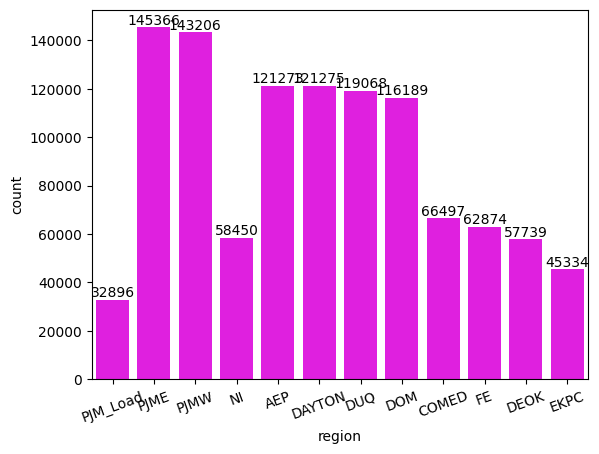

In [35]:
ax = sns.countplot(data=data, x='region',color='magenta')
ax.bar_label(ax.containers[0])

plt.xticks(rotation=20);

In [36]:
data.groupby('region')['Load'].mean().sort_values(ascending=False)

,Load
region,
PJME,32080.222831
PJM_Load,29766.427408
AEP,15499.513717
NI,11701.682943
COMED,11420.152112
DOM,10949.203625
FE,7792.159064
PJMW,5602.375089
DEOK,3105.096486


In [37]:
le = LabelEncoder()
le.fit(data['region'])
data['region'] = le.transform(data['region'])

In [38]:
data

,Datetime,Load,region
0,1998-04-01 01:00:00,22259.0,11
1,1998-04-01 02:00:00,21244.0,11
2,1998-04-01 03:00:00,20651.0,11
3,1998-04-01 04:00:00,20421.0,11
4,1998-04-01 05:00:00,20713.0,11
...,...,...,...
1090162,2018-08-03 00:00:00,35486.0,9
1090163,2018-08-03 00:00:00,5489.0,10
1090164,2018-08-03 00:00:00,1656.0,5
1090165,2018-08-03 00:00:00,11385.0,4


In [39]:
df = data

In [40]:
# hour: Günün saatını göstərir və elektrik istehlakının gün ərzindəki (məsələn, səhər və axşam) pik vaxtlarını müəyyən edir.
# dayofweek: Həftənin gününü rəqəmlə ifadə edir və iş günləri ilə istirahət günləri arasındakı fərqi üzə çıxarır.
# month: İlin ayını bildirir və mövsümi dəyişiklikləri (məsələn, yayda kondisioner, qışda isitmə istifadəsi) modelə tanıdır.
# is_weekend: Günün şənbə-bazar olub-olmadığını göstərən binar (0 və ya 1) dəyərdir və həftəsonu dəyişən yükü qeyd edir.
# lag_24: Dəqiq 24 saat əvvəlki yük miqdarıdır və modelə "dünən bu vaxt nə qədər enerji işlənmişdi?" sualının cavabını verir.
# lag_168: Bir həftə (168 saat) əvvəlki yük miqdarıdır və keçən həftənin eyni günü ilə müqayisə aparmağa imkan yaradır.
# rolling_mean_24: Son 24 saatın orta yük dəyəridir və datadakı qəfil sıçrayışları hamarlayaraq ümumi trendi göstərir.
# region: Məlumatın hansı paylayıcı zonaya aid olduğunu bildirir və modelin hər regionun özünəməxsus profilini tanımasını təmin edir.

In [41]:
def add_features(df):
    df = df.copy()
    df['hour']       = df['Datetime'].dt.hour
    df['dayofweek']  = df['Datetime'].dt.dayofweek
    df['month']      = df['Datetime'].dt.month
    df['is_weekend'] = (df['dayofweek'] >= 5).astype(int)

    # lag features
    df['lag_24']  = df.groupby('region')['Load'].shift(24)   # 1 gun evveli
    df['lag_168'] = df.groupby('region')['Load'].shift(168)  # 1 həftə evvel
    df['rolling_mean_24'] = df.groupby('region')['Load'].transform(
        lambda x: x.shift(1).rolling(24, min_periods=1).mean())

    df = df.dropna().reset_index(drop=True)
    return df

df = add_features(df)

In [42]:
df.head()

,Datetime,Load,region,hour,dayofweek,month,is_weekend,lag_24,lag_168,rolling_mean_24
0,1998-04-08 02:00:00,20826.0,11,2,2,4,0,21483.0,22259.0,26750.833333
1,1998-04-08 03:00:00,20279.0,11,3,2,4,0,21211.0,21244.0,26723.458333
2,1998-04-08 04:00:00,20118.0,11,4,2,4,0,21250.0,20651.0,26684.625000
3,1998-04-08 05:00:00,20503.0,11,5,2,4,0,21819.0,20421.0,26637.458333
4,1998-04-08 06:00:00,22243.0,11,6,2,4,0,23751.0,20713.0,26582.625000


In [43]:
from prophet import Prophet

sample = df[['Datetime', 'Load']].copy()
sample.columns = ['ds', 'y']
sample = sample.set_index('ds').resample('D').mean().reset_index()

m = Prophet(weekly_seasonality=True, yearly_seasonality=True)
m.fit(sample)

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [44]:
future   = m.make_future_dataframe(periods=365)
forecast = m.predict(future)

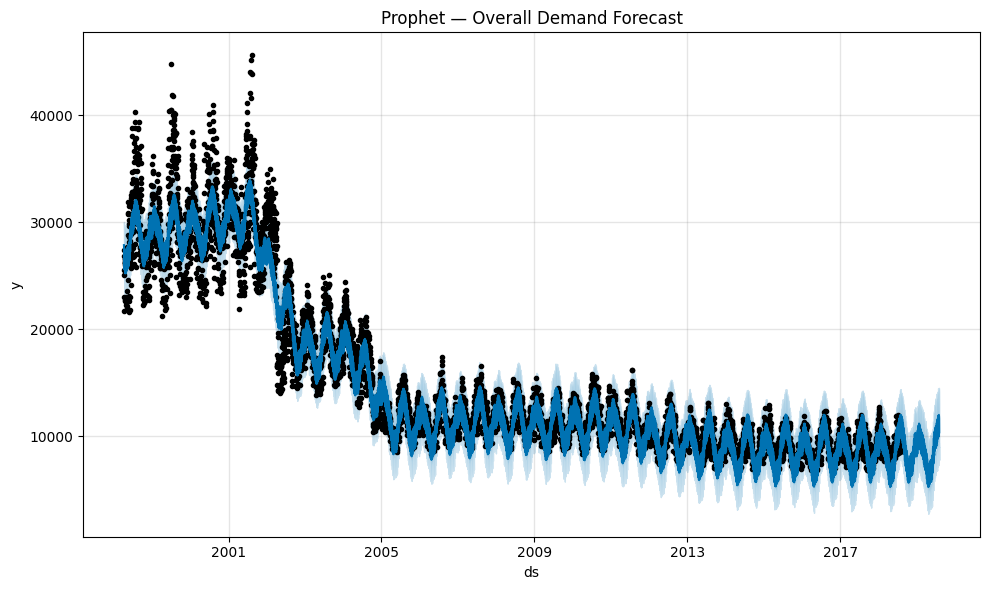

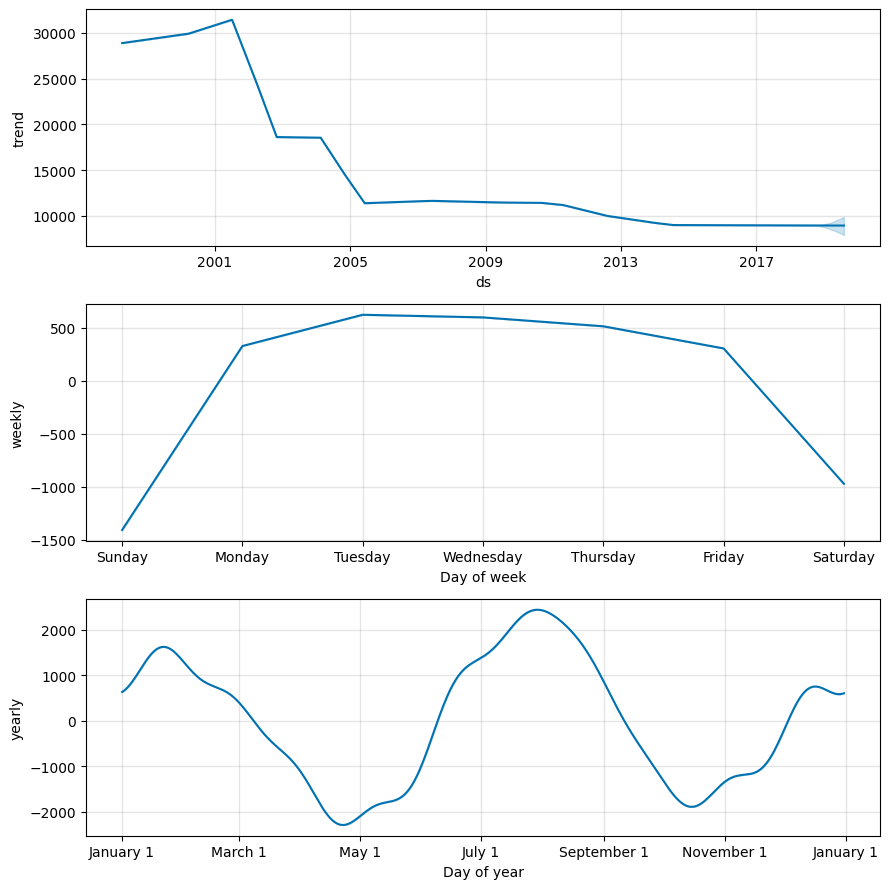

In [45]:
m.plot(forecast)
plt.title('Prophet — Overall Demand Forecast')
plt.tight_layout()
plt.show()

# (trend, weekly, yearly)
m.plot_components(forecast)
plt.tight_layout()
plt.show()

In [66]:
# --------------1. Iller ucun qrafik--------------------------
# 1998-2001 -> 30,000 MW   (yuksek)
# 2001-2005 → keskin enme
# 2005-2019 → 10,000 MW   (stabil, asagi)

# --------------1. Hefteler ucun qrafik--------------------------
# Bazar ertesi –? Cersenbe  → +500 MW  (yuksek)
# Senbe – Bazar → -1000/1500 MW (asagi)
# Sebeb is gunleri zavod, fabrik, ofislerin aciq olmasi istehlaki yukseldir

# --------------1. Aylar ucun qrafik--------------------------
# Yanvar       → +1500 MW  (isitme — yuxari)
# Aprel-May    → -2000 MW  (normal hava — en asagı)
# Iyul-Avqust  → +2200 MW  (soyutma — en yuxari)
# Noyabr       → -1800 MW  (azalma)
# Qis aylarinda isitme, yay aylarinda soyutmaya enerji cox serf olunur

In [52]:
# Train / Test Split
split = int(len(df)*0.2)
train_df = df.iloc[split:].copy()
test_df = df.iloc[:split].copy()

In [53]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error

features = ['hour', 'dayofweek', 'month', 'is_weekend',
            'lag_24', 'lag_168', 'rolling_mean_24', 'region']

xgb = XGBRegressor(n_estimators=500, learning_rate=0.03,
                   max_depth=10, random_state=42, n_jobs=-1)

xgb.fit(train_df[features], train_df['Load'])


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.03, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=10,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=-1, num_parallel_tree=None, ...)

In [54]:
test_df['pred'] = xgb.predict(test_df[features])

In [56]:

print(f"MAE : {mean_absolute_error(test_df['Load'], test_df['pred']):.2f}")
print(f"MAPE: {mean_absolute_percentage_error(test_df['Load'], test_df['pred']):.2f}%")

MAE : 536.85
MAPE: 0.03%


In [57]:
from sklearn.metrics import r2_score
print(f"R2  : {r2_score(test_df['Load'], test_df['pred']):.4f}")

R2  : 0.9946


## Visualization

In [58]:
import matplotlib.dates as mdates

regions = test_df['region'].unique()
region_labels = {
    0: 'PJM_Load', 1: 'PJME', 2: 'PJMW', 3: 'NI', 4: 'AEP',
    5: 'DAYTON', 6: 'DUQ', 7: 'DOM', 8: 'COMED', 9: 'FE',
    10: 'DEOK', 11: 'EKPC'
}

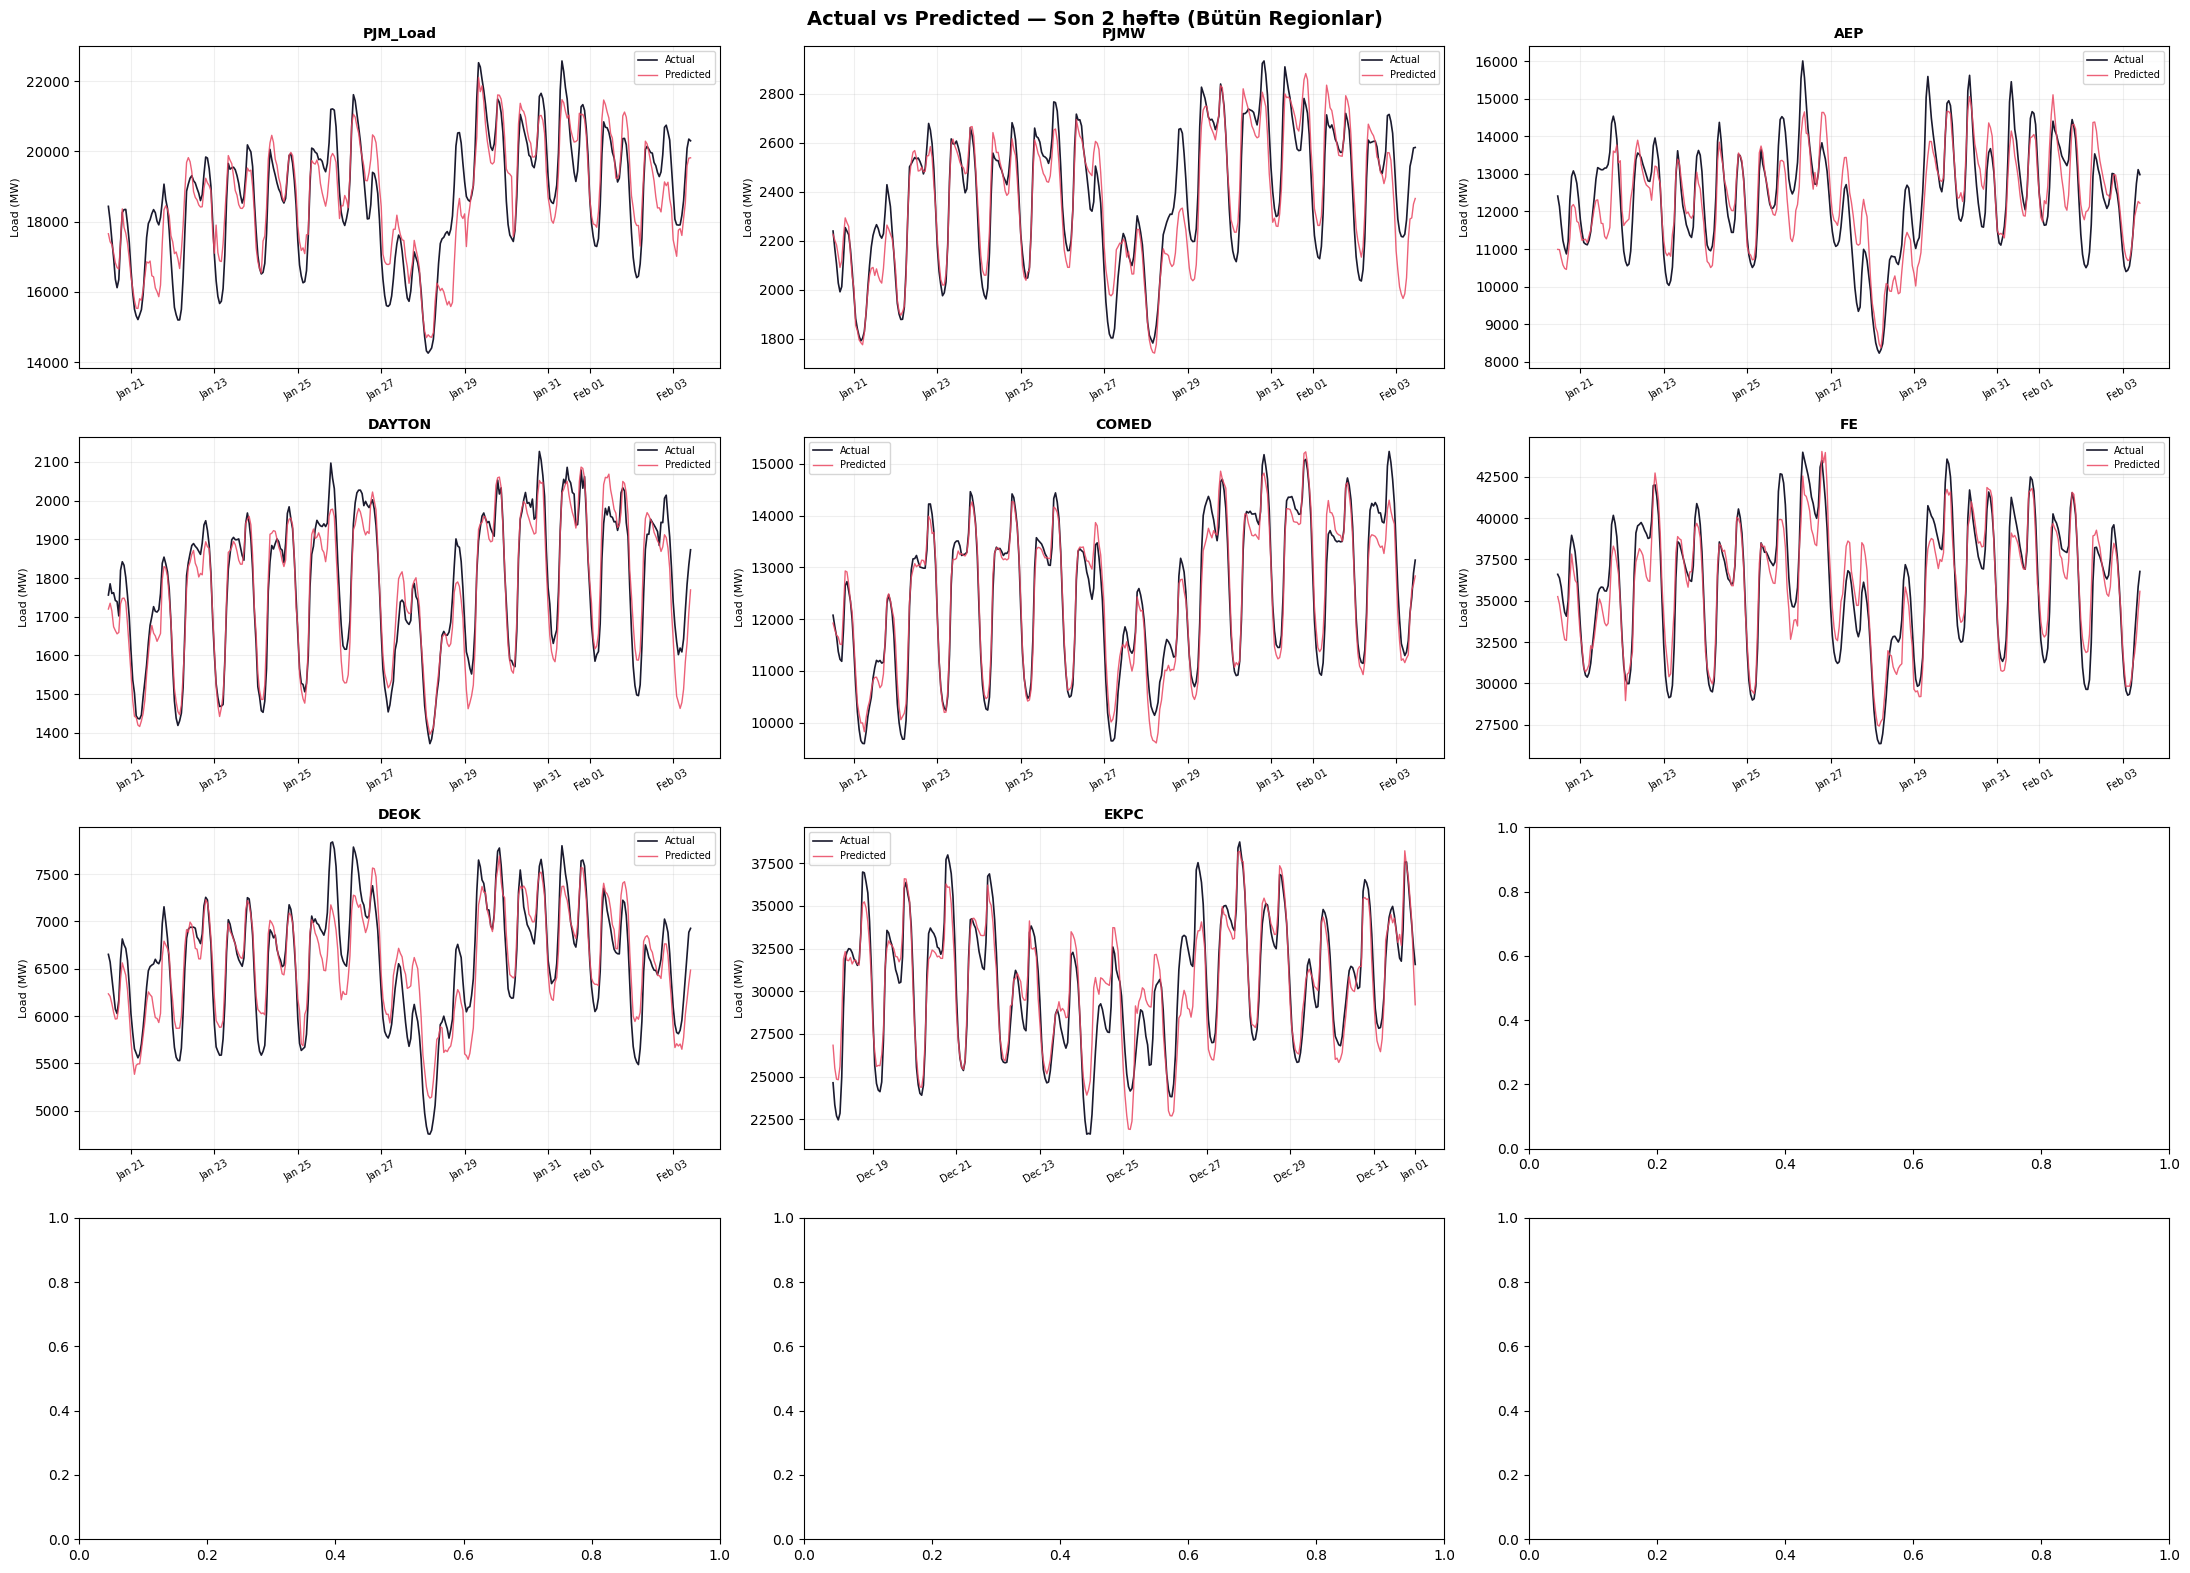

In [59]:
#  Hər region üçün Actual vs Predicted
# Hər regionda proqnozun real dataya nə qədər uyğun olduğu
fig, axes = plt.subplots(4, 3, figsize=(22, 16))
axes = axes.flatten()

for i, region in enumerate(sorted(regions)):
    te = test_df[test_df['region'] == region].tail(24 * 14)
    ax = axes[i]
    ax.plot(te['Datetime'], te['Load'],  label='Actual',    color='#1a1a2e', lw=1.2)
    ax.plot(te['Datetime'], te['pred'],  label='Predicted', color='#e94560', lw=1, alpha=0.85)
    ax.set_title(region_labels.get(region, region), fontsize=10, fontweight='bold')
    ax.legend(fontsize=7)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    ax.tick_params(axis='x', rotation=30, labelsize=7)
    ax.set_ylabel('Load (MW)', fontsize=8)
    ax.grid(alpha=0.2)

plt.suptitle('Actual vs Predicted — Son 2 həftə (Bütün Regionlar)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('actual_vs_pred.png', dpi=150, bbox_inches='tight')
plt.show()


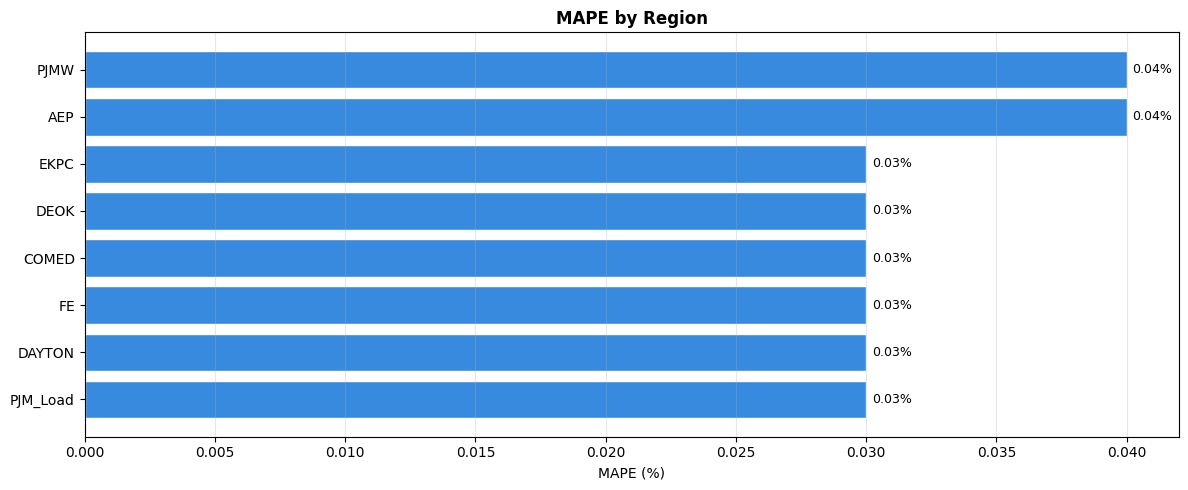

In [61]:
# MAPE hər region üçün bar chart
# Hansı region MAPE  daha dəqiq proqnoz edilib
summary = []
for region in sorted(regions):
    te = test_df[test_df['region'] == region]
    m  = mean_absolute_percentage_error(te['Load'], te['pred'])
    summary.append({'Region': region_labels.get(region, region), 'MAPE': round(m, 2)})

res = pd.DataFrame(summary).sort_values('MAPE')

fig2, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(res['Region'], res['MAPE'], color='#378ADD', edgecolor='white')
ax.bar_label(bars, fmt='%.2f%%', padding=4, fontsize=9)
ax.set_xlabel('MAPE (%)')
ax.set_title('MAPE by Region', fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('mape_by_region.png', dpi=150, bbox_inches='tight')
plt.show()


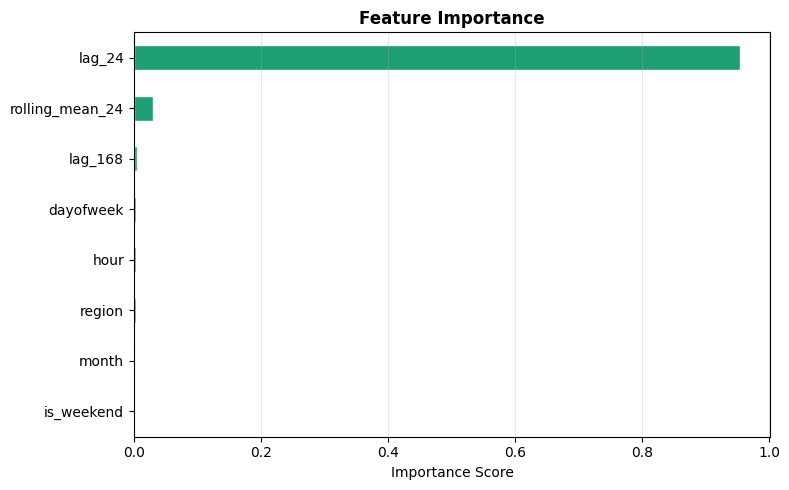

In [62]:
# Feature Importance
# Hansı sütun modelin qərarına daha çox təsir edir
FEATURES = ['hour', 'dayofweek', 'month', 'is_weekend',
            'lag_24', 'lag_168', 'rolling_mean_24', 'region']

feat_imp = pd.Series(xgb.feature_importances_, index=FEATURES).sort_values()

fig3, ax = plt.subplots(figsize=(8, 5))
feat_imp.plot(kind='barh', ax=ax, color='#1D9E75', edgecolor='white')
ax.set_title('Feature Importance', fontweight='bold')
ax.set_xlabel('Importance Score')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

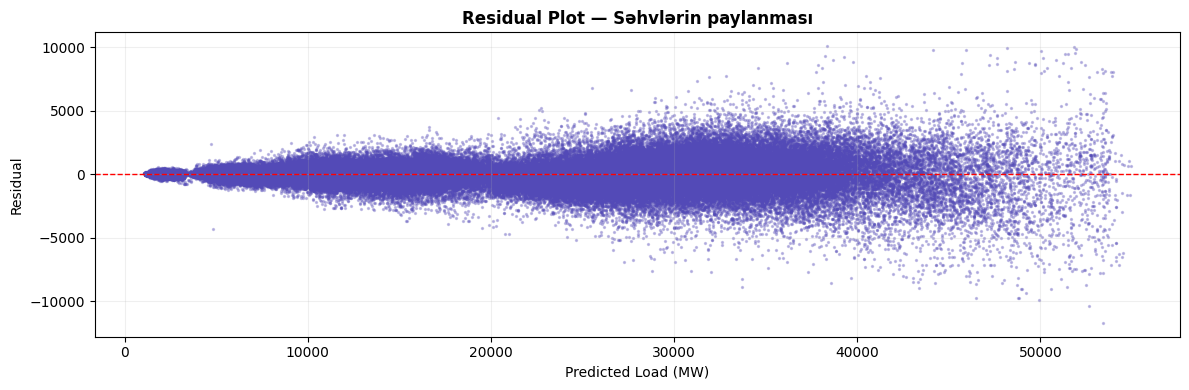

In [63]:
#  Residual Plot
# Modelin sistematik xətası varmı
test_df['residual'] = test_df['Load'] - test_df['pred']

fig4, ax = plt.subplots(figsize=(12, 4))
ax.scatter(test_df['pred'], test_df['residual'],
           alpha=0.3, s=2, color='#534AB7')
ax.axhline(0, color='red', lw=1, ls='--')
ax.set_xlabel('Predicted Load (MW)')
ax.set_ylabel('Residual')
ax.set_title('Residual Plot — Səhvlərin paylanması', fontweight='bold')
ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig('residuals.png', dpi=150, bbox_inches='tight')
plt.show()